# Notebook Overview

This notebook continues the Online Retail analysis by building customer value and churn diagnostics from the cleaned dataset.

The workflow is organized into a few connected stages:
1. Load the cleaned retail workbook and calculate a `TotalPrice` field.
2. Build RFM metrics for recency, frequency, and monetary value.
3. Create customer cohorts and evaluate retention patterns across time.
4. Estimate churn using a rolling inactivity threshold.
5. Explore whether simple value-based features can help explain churn behavior.

Notebook notes:
- Negative `Quantity` values are treated as returns or refunds and removed from the customer behavior analysis.
- The analysis is interpretive rather than strictly prescriptive; several thresholds are chosen to reflect a practical business-use example.
- Any final model or decision should be validated with a broader business context and a more complete feature set.


In [90]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.weightstats import ztest

import warnings
warnings.filterwarnings("ignore")

In [6]:
# Read in cleaned data
data = pd.read_excel('./Data/Online Retail_clean.xlsx',
                header = 0)

In [7]:
data.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
# Calculate TotalPrice of an invoice
data['TotalPrice'] = data['Quantity']*data['UnitPrice']

Assuming negative `Quantity` values represent returns or refunds, the notebook removes them for the purposes of customer behavior analysis.

This keeps the later RFM and churn calculations aligned with actual purchasing activity rather than mixed sales and reversal activity.


In [26]:
# Take out invoices with negative quantities
data_filtered = data[data['Quantity'] >= 0]

___
___

# RFM Analysis

RFM stands for recency, frequency, and monetary value. This notebook uses that framework to understand customer value by measuring:
- how recently a customer made a purchase (`Recency`)
- how often they purchase (`Frequency`)
- how much they spend (`Monetary`)

This structure is commonly used for customer segmentation, retention targeting, and identifying high-value accounts.

## Recency
Recency is the measurement of how recent a customer's last purchase or invoice was.


In [27]:
# Aggregate original data by CustomerID to
# get number of unique Invoices
# and the date of the last invoice
days_since_last = data_filtered\
                    .groupby(['CustomerID','Country'])\
                    .agg({'InvoiceNo':'nunique',
                          'InvoiceDate':'max'})

In [28]:
# Calculate the number of days since last purchase
## Go from Jan 1, 2012 to simulate data analysis 
## on a narrower timescale
days_since_last['day_since_last_purchase'] = (datetime.datetime.strptime('01012012','%m%d%Y') - days_since_last['InvoiceDate']).dt.days

In [29]:
last_invoice = days_since_last.sort_values(['InvoiceNo',
                                             'InvoiceDate'],
                                            ascending = False)\
                                .rename({'InvoiceDate':'LastInvoiceDate',
                                        'InvoiceNo':'NumInvoices'},
                                        axis = 1)

In [30]:
last_invoice.head()

,,NumInvoices,LastInvoiceDate,day_since_last_purchase
CustomerID,Country,,,
12748.0,United Kingdom,210,2011-12-09 12:20:00,22
14911.0,EIRE,201,2011-12-08 15:54:00,23
17841.0,United Kingdom,124,2011-12-08 12:07:00,23
13089.0,United Kingdom,97,2011-12-07 09:02:00,24
14606.0,United Kingdom,93,2011-12-08 19:28:00,23


## Frequency
Frequency measures how many purchases a customer has made and how regularly they make them.

The notebook computes this by looking at invoice dates, removing duplicates, and measuring the average gap between purchase events.


In [31]:
def days_between_purchases(group):
    # Custom groupby function to get the number of days between purchases
    # Get the InvoiceDate of each order and remove duplicates. Sort by date
    group_sorted = group[['InvoiceDate']]\
                    .drop_duplicates()\
                    .sort_values('InvoiceDate', ascending = True)

    # Calculate the number of days between purchase dates
    group_sorted['days_between_last_purchase'] = (group_sorted['InvoiceDate'] - group_sorted['InvoiceDate'].shift(1)).dt.days

    return group_sorted[['InvoiceDate', 'days_between_last_purchase']]

In [32]:
days_between_purchases = data_filtered.groupby(['CustomerID','Country'])\
                            .apply(days_between_purchases)\
                            .droplevel(2)\
                            .reset_index()

In [118]:
# Aggregate by CustomerID to get the total number of InvoiceDate, the average time between them, and variance of time between them
avg_days_between = days_between_purchases\
                    .groupby(['CustomerID','Country'])\
                    .agg({'InvoiceDate':'count',
                          'days_between_last_purchase':['mean','var']})

In [119]:
avg_days_between.columns = ['NumInvoices', 'AvgDaysBetweenPurchases', 'VarDaysBetweenPurchases']

In [120]:
avg_days_between.sort_values(['NumInvoices',
                             'AvgDaysBetweenPurchases'],
                             ascending = False,
                            inplace = True)

In [121]:
avg_days_between.head()

,,NumInvoices,AvgDaysBetweenPurchases,VarDaysBetweenPurchases
CustomerID,Country,,,
12748.0,United Kingdom,211,1.419048,9.756573
14911.0,EIRE,201,1.470000,7.295578
17841.0,United Kingdom,124,2.552846,3.511529
14606.0,United Kingdom,95,3.500000,4.231183
13089.0,United Kingdom,93,3.619565,19.007525


## Monetary
Monetary captures how much each customer has spent in total and the average spend per invoice.

This allows the notebook to distinguish not only between frequent customers, but also between customers whose value comes from larger basket sizes or higher transaction intensity.


In [101]:
# Calculate the total amount spent per customer
customer_total_spent = data_filtered.groupby(['CustomerID','Country'])\
                        [['InvoiceNo','TotalPrice']]\
                        .agg({'InvoiceNo':'nunique',
                              'TotalPrice':'sum'})\
                        .sort_values('TotalPrice',
                                     ascending = False)\
                        .rename({'InvoiceNo':'NumInvoices',
                                 'TotalPrice':'TotalSpend'},
                                axis = 1)

In [102]:
# On average, how much does each customer spend
customer_total_spent['AvgSpend'] = customer_total_spent['TotalSpend']/customer_total_spent['NumInvoices']

In [103]:
customer_total_spent.head()

,,NumInvoices,TotalSpend,AvgSpend
CustomerID,Country,,,
14646.0,Netherlands,74,280206.02,3786.567838
18102.0,United Kingdom,60,259657.30,4327.621667
17450.0,United Kingdom,46,194550.79,4229.365000
16446.0,United Kingdom,2,168472.50,84236.250000
14911.0,EIRE,201,143825.06,715.547562


## Merging RFM

In [122]:
# Merge recency, frequency, and monetary data into one
rfm_merge = pd.merge(pd.merge(last_invoice,
                             avg_days_between.drop('NumInvoices',
                                                   axis = 1),
                             how = 'outer',
                             left_index = True,
                             right_index = True),
                    customer_total_spent.drop('NumInvoices',
                                              axis = 1),
                    how = 'outer',
                    left_index = True,
                    right_index = True)

In [123]:
rfm_merge.head()

,,NumInvoices,LastInvoiceDate,day_since_last_purchase,AvgDaysBetweenPurchases,VarDaysBetweenPurchases,TotalSpend,AvgSpend
CustomerID,Country,,,,,,,
12346.0,United Kingdom,1,2011-01-18 10:01:00,347,NaN,NaN,77183.60,77183.600000
12347.0,Iceland,7,2011-12-07 15:52:00,24,60.333333,341.466667,4310.00,615.714286
12348.0,Finland,4,2011-09-25 13:13:00,97,94.000000,4921.000000,1797.24,449.310000
12349.0,Italy,1,2011-11-21 09:51:00,40,NaN,NaN,1757.55,1757.550000
12350.0,Norway,1,2011-02-02 16:01:00,332,NaN,NaN,334.40,334.400000


In [124]:
with pd.ExcelWriter('./Data/Online Retail_Analysis.xlsx',
                    mode = 'w') as writer:
    rfm_merge.to_excel(writer,
                       sheet_name = 'RFM',
                       index = True)

___
___
# Cohort Analysis

Cohort analysis groups customers by their first purchase period so the notebook can compare retention and customer behavior across cohorts over time.

This is useful for spotting whether newer customers behave differently from older ones and whether a specific acquisition period appears more stable or more at risk of churn.


In [43]:
# Get the date of a customers first invoice
first_purchase_date = data_filtered\
                        .groupby(['CustomerID','Country'],
                                dropna = False)\
                        [['InvoiceDate']]\
                        .min()\
                        .rename({'InvoiceDate':'FirstInvoiceDate'},
                                axis = 1)

In [44]:
# Create cohorts based upon FirstInvoiceDate
first_purchase_date['Cohort'] = first_purchase_date['FirstInvoiceDate'].apply(lambda x: datetime.datetime.strftime(x,'%b %Y'))

In [45]:
# Merge the Cohort onto the original data
data_cohorts = pd.merge(data_filtered,
                        first_purchase_date,
                        how = 'left',
                        left_on = ['CustomerID','Country'],
                        right_index = True)

In [46]:
# Get the cohort index, how many months from cohort month
data_cohorts['CohortIndex'] = (data_cohorts['InvoiceDate'].dt.to_period('M') - data_cohorts['FirstInvoiceDate'].dt.to_period('M')).apply(lambda x: x.n)

In [47]:
data_cohorts

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,FirstInvoiceDate,Cohort,CohortIndex
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01 08:26:00,Dec 2010,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00,Dec 2010,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01 08:26:00,Dec 2010,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00,Dec 2010,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01 08:26:00,Dec 2010,0
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011-08-18 15:44:00,Aug 2011,4
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011-08-18 15:44:00,Aug 2011,4
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-08-18 15:44:00,Aug 2011,4
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-08-18 15:44:00,Aug 2011,4


In [48]:
# Export cohort data to excel
with pd.ExcelWriter('./Data/Online Retail_Analysis.xlsx',
                   mode = 'a',
                   if_sheet_exists = 'replace') as writer:
    data_cohorts.to_excel(writer,
                          sheet_name = 'Cohorts',
                          index = False)                     

## Retention

Retention is evaluated by tracking each cohort over monthly cohort indices and comparing how many customers remain active from one month to the next.

The notebook normalizes each cohort against its initial month so the retention trend can be interpreted as a percentage rather than a raw customer count.


In [49]:
# Pivot cohort data to get number of unique customers per cohort
# Take out December 2011 due to incomplete data
cohort_retention_values = pd.pivot_table(data_cohorts[data_cohorts['InvoiceDate'] < datetime.datetime.strptime('12-2011','%m-%Y')],
                                         index = 'Cohort',
                                         columns = 'CohortIndex',
                                         values = 'CustomerID',
                                         aggfunc = 'nunique')

In [50]:
# Convert index into datetime objects
cohort_retention_values.index = pd.to_datetime(cohort_retention_values.index,
                                               format = '%b %Y')

In [51]:
cohort_retention_values.sort_index(inplace = True)

In [52]:
# Divide values in each row by the first (0) CohortIndex
## Gets the percentage of a cohort retained each proceeding month
cohort_retention_pct = cohort_retention_values.divide(cohort_retention_values.loc[:,0],
                                                      axis = 0)\
                        * 100

In [53]:
# Export cohort data to excel
with pd.ExcelWriter('./Data/Online Retail_Analysis.xlsx',
                   mode = 'a',
                   if_sheet_exists = 'replace') as writer:
    cohort_retention_pct.to_excel(writer,
                          sheet_name = 'Cohorts Pct',
                          index = False)                     

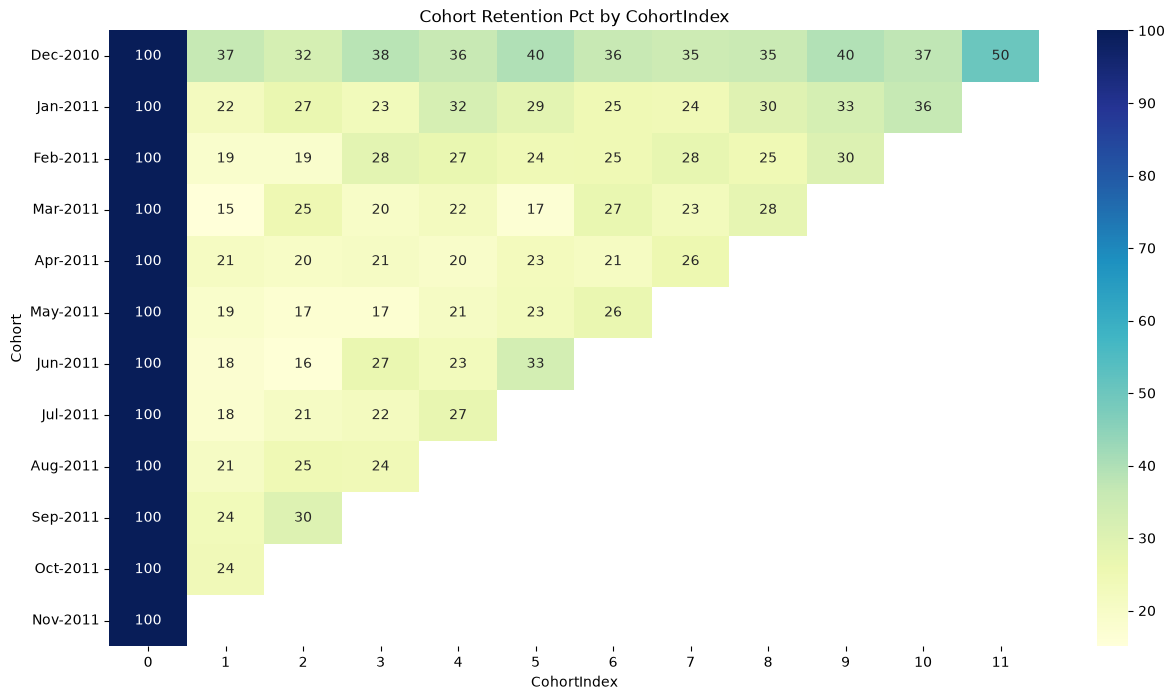

In [54]:
# Plot the cohort retention percentage
fig, ax = plt.subplots(figsize = (15, 8))
sns.heatmap(cohort_retention_pct,
            annot = True,
            cmap = 'YlGnBu',
            fmt = '.0f',
            ax = ax)

yticklabels = [cohort_retention_pct.index[int(tick)].strftime('%b-%Y')
               for tick in ax.get_yticks()]
ax.set_yticklabels(yticklabels)
ax.set_title('Cohort Retention Pct by CohortIndex')
plt.show()

In [55]:
# Melt the pivoted cohorts to plot line graphs
cohort_retention_melted = pd.melt(cohort_retention_pct.drop(0, axis = 1),
                                  ignore_index = False)\
                            .dropna()\
                            .rename({'value':'RetentionRate'},
                                    axis = 1)\
                            .reset_index()

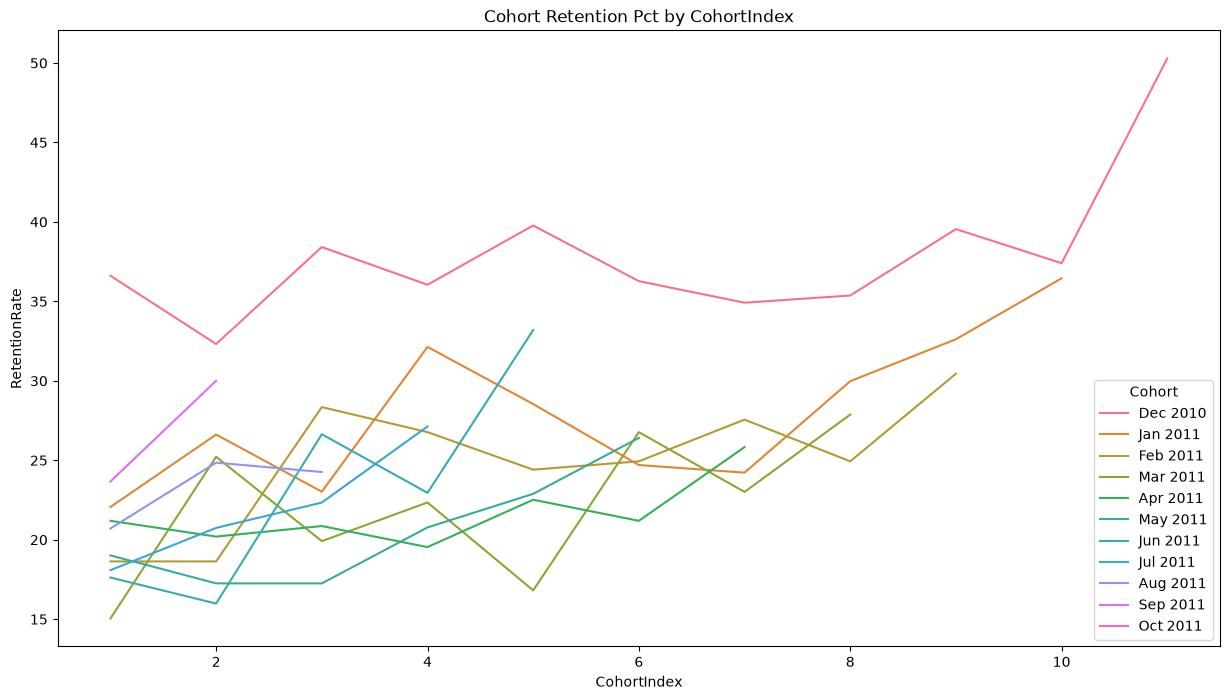

In [56]:
# Plot line charts by Cohort
fig, ax = plt.subplots(figsize = (15, 8))
sns.lineplot(cohort_retention_melted,
             x = 'CohortIndex',
             y = 'RetentionRate',
             hue = cohort_retention_melted['Cohort'].dt.strftime('%b %Y'),
            ax = ax)
ax.set_title('Cohort Retention Pct by CohortIndex')
plt.show()

C:\Users\Curtis\AppData\Local\Temp\ipykernel_12888\2016752690.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([cohort.strftime('%b %Y')


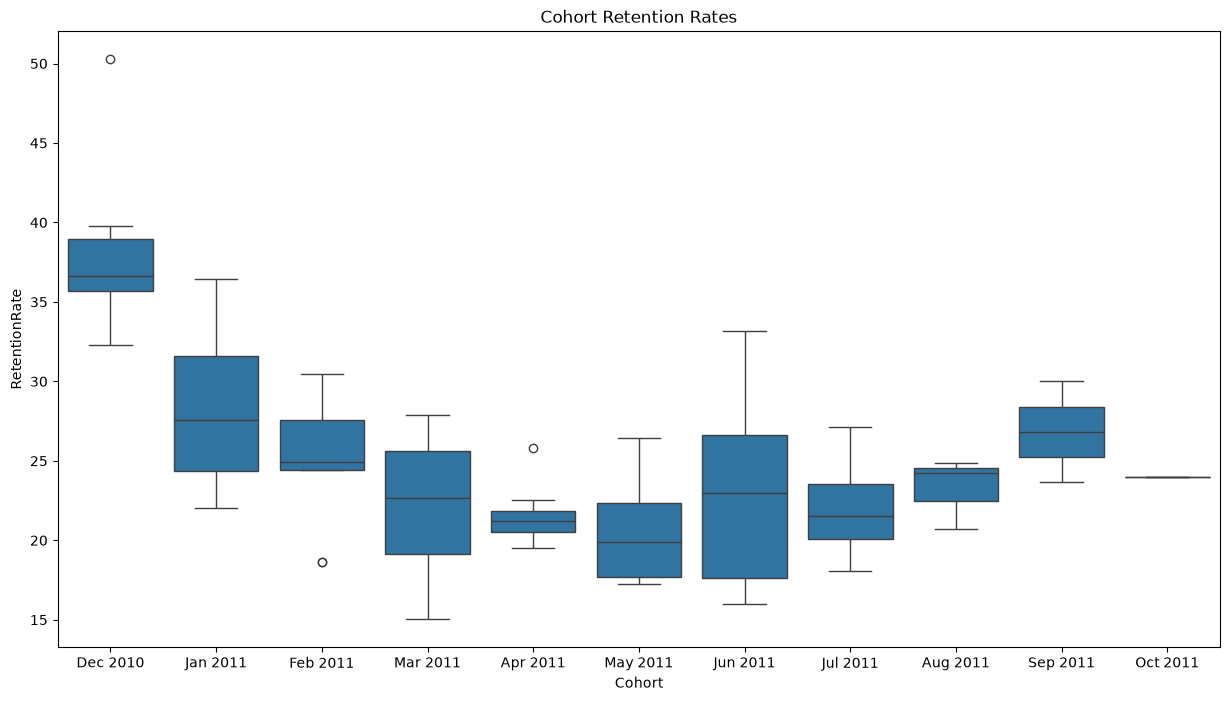

In [57]:
# Plot line charts by CohortIndex
fig, ax = plt.subplots(figsize = (15, 8))
sns.boxplot(cohort_retention_melted,
             x = 'Cohort',
             y = 'RetentionRate',
            ax = ax)
ax.set_title('Cohort Retention Rates')
ax.set_xticklabels([cohort.strftime('%b %Y')
                     for cohort
                     in sorted(cohort_retention_melted['Cohort'].unique())])
plt.show()

By looking at the previous charts, it is clear that the first cohort, December 2010, shows the strongest repeat-customer behavior. It also appears to retain customers more steadily than later cohorts, although that observation alone does not determine which cohort is the most monetarily valuable.

This motivates the follow-up monetary analysis, where value is examined in terms of spend per customer over time.


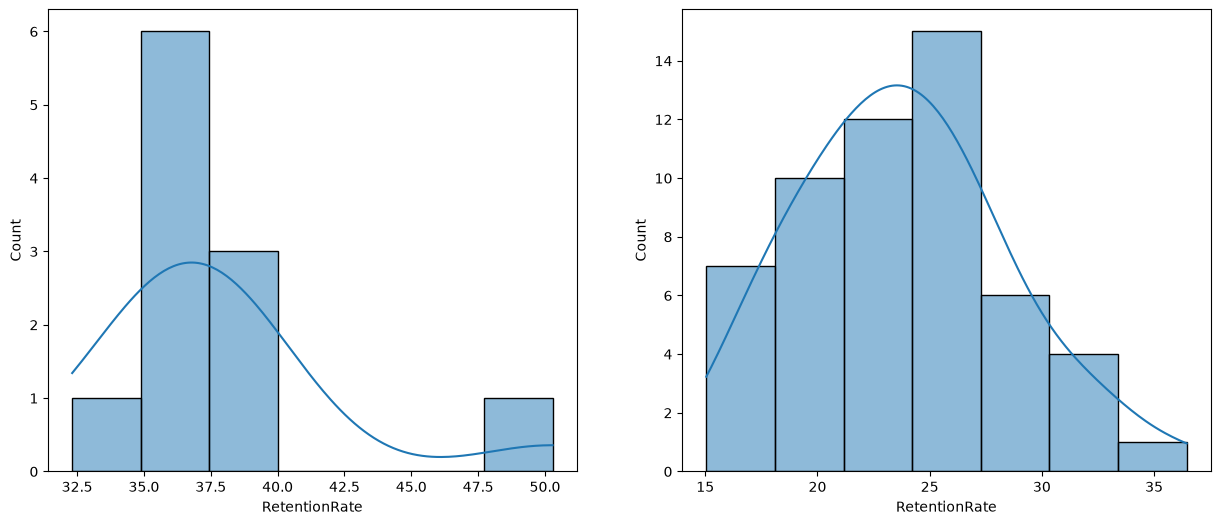

In [58]:
figure, (ax1, ax2) = plt.subplots(nrows = 1,
                                  ncols = 2,
                                  figsize = (15,6))

sns.histplot(cohort_retention_melted[cohort_retention_melted['Cohort'] == '2010-12-01']['RetentionRate'],
             kde = True,
           ax = ax1)

sns.histplot(cohort_retention_melted[cohort_retention_melted['Cohort'] != '2010-12-01']['RetentionRate'],
             kde = True,
           ax = ax2)

plt.show()

In [59]:
t_stat, p_val = stats.ttest_ind(cohort_retention_melted[cohort_retention_melted['Cohort'] == '2010-12-01']['RetentionRate'],
                                cohort_retention_melted[cohort_retention_melted['Cohort'] != '2010-12-01']['RetentionRate'],
                               alternative = 'greater')

print(t_stat)
print(p_val)

# Significance level
alpha = 0.05
if p_val <= alpha:
    print("The null hypothesis is rejected. The first cohort retention rate is different from the other cohorts.")
else:
    print("The null hypothesis is not rejected. The first cohort retention rate is not different from the other cohorts.")

9.146194540570955
1.572612722910332e-13
The null hypothesis is rejected. The first cohort retention rate is different from the other cohorts.


Albeit small sample sizes, it appears as though the first cohort (Dec 2010) has a better retention rate when compared to the other cohorts.

## Cohort Monetary Value

This section compares cohorts by monetary output over time, using both total spend and spend-per-customer metrics.

The goal is to determine whether the stronger retention signal observed in earlier cohorts also translates into higher revenue contribution.


In [60]:
cohort_value = data_cohorts.groupby([pd.to_datetime(data_cohorts['Cohort'],
                                                   format = '%b %Y'),
                                     'CohortIndex'])\
                    [['CustomerID','InvoiceNo','TotalPrice']]\
                    .agg({'CustomerID':'nunique',
                          'InvoiceNo':'nunique',
                          'TotalPrice':'sum'})\
                    .reset_index()

In [61]:
cohort_value['TotalPricePerCustomer'] = cohort_value['TotalPrice']/cohort_value['CustomerID']
cohort_value['TotalPricePerInvoice'] = cohort_value['TotalPrice']/cohort_value['InvoiceNo']

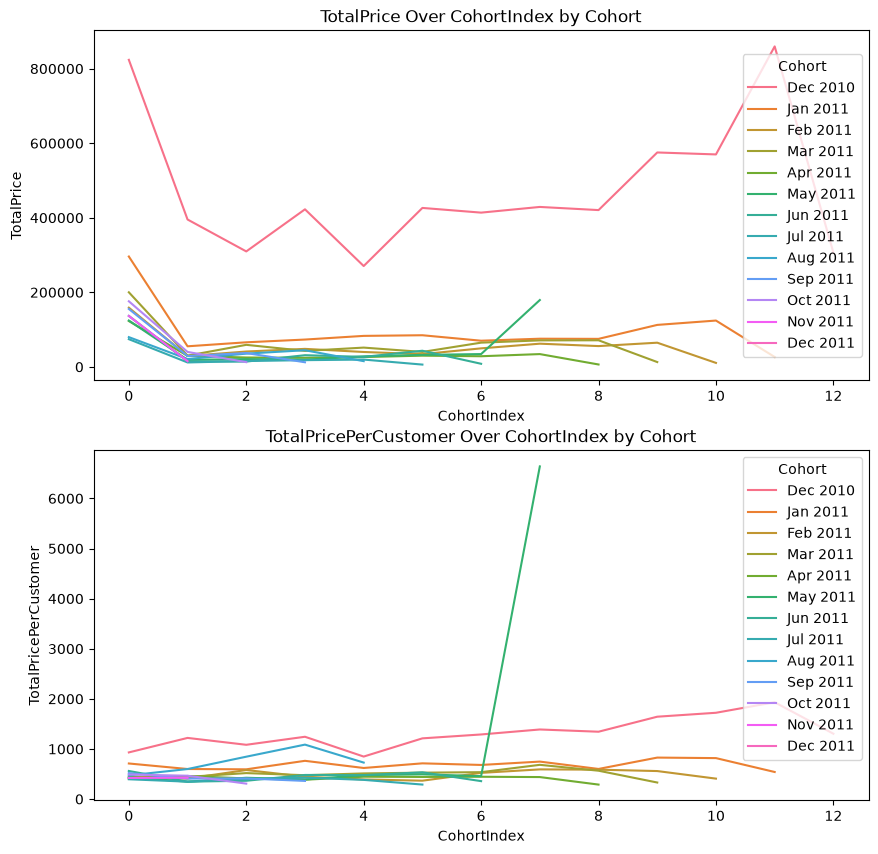

In [62]:
figure, (ax1, ax2) = plt.subplots(nrows = 2,
                                  ncols = 1,
                          figsize = (10, 10))

# Month over month (CohortIndex) TotalPrice spent by cohort 
sns.lineplot(cohort_value,
             x = 'CohortIndex',
             y = 'TotalPrice',
             hue = cohort_value['Cohort'].dt.strftime('%b %Y'),
             ax = ax1)
ax1.set_title('TotalPrice Over CohortIndex by Cohort')

# Month over month (CohortIndex) TotalPrice per CustomerID by cohort
sns.lineplot(cohort_value,
             x = 'CohortIndex',
             y = 'TotalPricePerCustomer',
             hue = cohort_value['Cohort'].dt.strftime('%b %Y'),
             ax = ax2)
ax2.set_title('TotalPricePerCustomer Over CohortIndex by Cohort')

plt.show()

In [63]:
cohort_customer_spend = data_cohorts.groupby(['Cohort',\
                                              'CustomerID',
                                              'Country',
                                              pd.Grouper(key = 'InvoiceDate',
                                                         freq = '1D')])\
                            [['TotalPrice']]\
                            .sum()\
                            .reset_index()

In [64]:
# Perform the two-sample z-test
# value=0 means we test the null hypothesis that the difference between means is zero (mean_A = mean_B)
z_stat, p_value = ztest(x1 = cohort_customer_spend[cohort_customer_spend['Cohort'] == 'Dec 2010']['TotalPrice'],
                             x2 = cohort_customer_spend[cohort_customer_spend['Cohort'] != 'Dec 2010']['TotalPrice'],
                             value = 0,
                             alternative = 'larger')

print(z_stat)
print(p_value)

# Significance level
alpha = 0.05
if p_value <= alpha:
    print("The null hypothesis is rejected. The first cohort spends more than the other cohorts.")
else:
    print("The null hypothesis is not rejected. The first cohort doesn't spend more than the other cohorts.")

5.545083200271025
1.469072134295437e-08
The null hypothesis is rejected. The first cohort spends more than the other cohorts.


# Churn Rate

Churn rate is the percentage of customers who become inactive over a selected time period. In this notebook, churn is approached as a customer inactivity problem: after a long gap in purchases, the customer is considered to have churned.

This gives the analysis a simple operational definition that can be used for a rolling time-series view of customer retention.


## Consolidate Daily Transactions

To simplify the churn analysis, transactions are consolidated by customer and by day. This removes intra-day invoice noise and produces a cleaner sequence of purchase activity for each customer.

The resulting daily series is then used to estimate customer inactivity and define a churn window.


In [65]:
# Group and resample data by CustomerID, Country, and InvoiceDate by day
## Remove negative values
data_grouped = data_filtered\
                    .groupby(['CustomerID',
                             'Country',
                             pd.Grouper(key = 'InvoiceDate',
                                        freq = '1D')])\
                    [['Quantity','TotalPrice']]\
                    .sum()\
                    .reset_index()

## Mean Days Between Transactions

This section estimates the average time between repeat-purchase events so a practical churn threshold can be chosen.

The threshold is intentionally a business-use example rather than a universal rule. A smaller threshold would make churn appear more frequent, while a larger threshold would delay the churn signal.


In [66]:
def mean_tbp(group):
    group['Previous Invoice Date'] = group['InvoiceDate'].shift(1)

    group['TBP'] = (group['InvoiceDate'] - group['Previous Invoice Date']).dt.days

    mean_tbp = group[['TBP']].mean()

    return mean_tbp

In [67]:
customer_mean_tbp = data_grouped.groupby(['CustomerID','Country']).apply(mean_tbp)

In [68]:
rfm_merge['AvgDaysBetweenPurchases'].mean()

np.float64(72.30416912768372)

In [69]:
print('Average time between purchases: %.2f' %customer_mean_tbp['TBP'].mean())

Average time between purchases: 78.48


Since the average number of days between purchases for repeat customers is roughly 79 days, a churn threshold in that vicinity—plus a small buffer—is a reasonable starting point.

In this notebook, the threshold is set to 90 days for a simple illustrative rule. That choice is meant to create a stable operational definition, not to claim that 90 days is the only valid churn cutoff.


## Rolling Churn Rate

Once a churn threshold has been set, the notebook evaluates how the churn rate evolves over time.

This gives a rolling perspective on customer inactivity and helps determine whether the business is retaining customers at a stable rate or losing activity over time.


In [70]:
def calculate_rolling_churn(group):
    # Custom groupby function to get determine if customer churned since last purchase
    # Get the InvoiceDate of each order and remove duplicates. Sort by date
    group_dropped = group[['InvoiceDate','Quantity','TotalPrice']]\
                    .drop_duplicates()

    group_consolidated = group_dropped\
                            .groupby('InvoiceDate')\
                            .sum()

    # Set rolling period
    rolling_period = 90
    
    group_rolling = group_consolidated.rolling(rolling_period, 
                                               min_periods = 1)\
                    .sum()\
                    .reset_index()

    group_rolling['Churn'] = (group_rolling['InvoiceDate'].shift(-1,
                                                                fill_value = datetime.datetime.strptime('01012012', '%m%d%Y'))\
                             - group_rolling['InvoiceDate']).dt.days > 90

    group_rolling['Churn Date'] = group_rolling['InvoiceDate'] + pd.DateOffset(days = 90)
    
    return group_rolling

In [71]:
# Determine which customers churned. Can use days_between_purchases data
data_agg = data_grouped\
            .groupby(['CustomerID', 'Country'])\
            [['InvoiceDate','Quantity','TotalPrice']]\
            .apply(calculate_rolling_churn)\
            .droplevel(2)\
            .reset_index()

In [72]:
data_agg.rename(columns = {'Quantity':'RollingQuantity',
                           'TotalPrice':'RollingTotalPrice'},
                inplace = True)

In [73]:
# List of customers by day
data_daily_customers = data_agg.groupby(pd.Grouper(key = 'InvoiceDate',
                                                   freq = 'D'))\
                                .apply(lambda x: x['CustomerID'].unique())

In [75]:
# Resample list of customers by month
data_resample_monthly = data_daily_customers.resample('ME')\
                                            .apply(lambda x: [item for i in x
                                                              for item in i])

In [76]:
# Get 3 month rolling list of unique customers
rolling_customers = pd.DataFrame()

for i in range(2, len(data_resample_monthly.index)):
    rolling_customers.loc[data_resample_monthly.index[i],
                            '3 Month Rolling Unique Customers'] = len(set([*data_resample_monthly.iloc[i-2],
                                                                           *data_resample_monthly.iloc[i-1],
                                                                           *data_resample_monthly.iloc[i]]))

In [78]:
# Number of customers churned in given month
monthly_churn_customers = data_agg.groupby(pd.Grouper(key =  'Churn Date',
                                                      freq = 'ME'))\
                                    .apply(lambda x: x[x['Churn'] == True][['CustomerID']].nunique())\
                                    .rename(columns = {'CustomerID':'Churned Customers'})

In [79]:
# Join number of monthly customers and monthly churned
monthly_churn_stats = pd.merge(rolling_customers,
                               monthly_churn_customers,
                               how = 'inner',
                               left_index = True,
                               right_index = True)

In [80]:
monthly_churn_stats['Churn Rate'] = monthly_churn_stats['Churned Customers']/monthly_churn_stats['3 Month Rolling Unique Customers']

In [81]:
monthly_churn_stats

,3 Month Rolling Unique Customers,Churned Customers,Churn Rate
2011-03-31,1776.0,410,0.230856
2011-04-30,1874.0,272,0.145144
2011-05-31,1993.0,342,0.171601
2011-06-30,1991.0,387,0.194375
2011-07-31,2030.0,305,0.150246
2011-08-31,1948.0,429,0.220226
2011-09-30,2161.0,383,0.177233
2011-10-31,2480.0,330,0.133065
2011-11-30,2852.0,274,0.096073
2011-12-31,2561.0,413,0.161265


In [82]:
# Get average 
customer_churn_pct = monthly_churn_stats['Churned Customers'].sum()/monthly_churn_stats['3 Month Rolling Unique Customers'].sum()

print('Average monthly churn rate: %f' % (customer_churn_pct * 100))

Average monthly churn rate: 16.362042


In [83]:
monthly_churn_stats

,3 Month Rolling Unique Customers,Churned Customers,Churn Rate
2011-03-31,1776.0,410,0.230856
2011-04-30,1874.0,272,0.145144
2011-05-31,1993.0,342,0.171601
2011-06-30,1991.0,387,0.194375
2011-07-31,2030.0,305,0.150246
2011-08-31,1948.0,429,0.220226
2011-09-30,2161.0,383,0.177233
2011-10-31,2480.0,330,0.133065
2011-11-30,2852.0,274,0.096073
2011-12-31,2561.0,413,0.161265


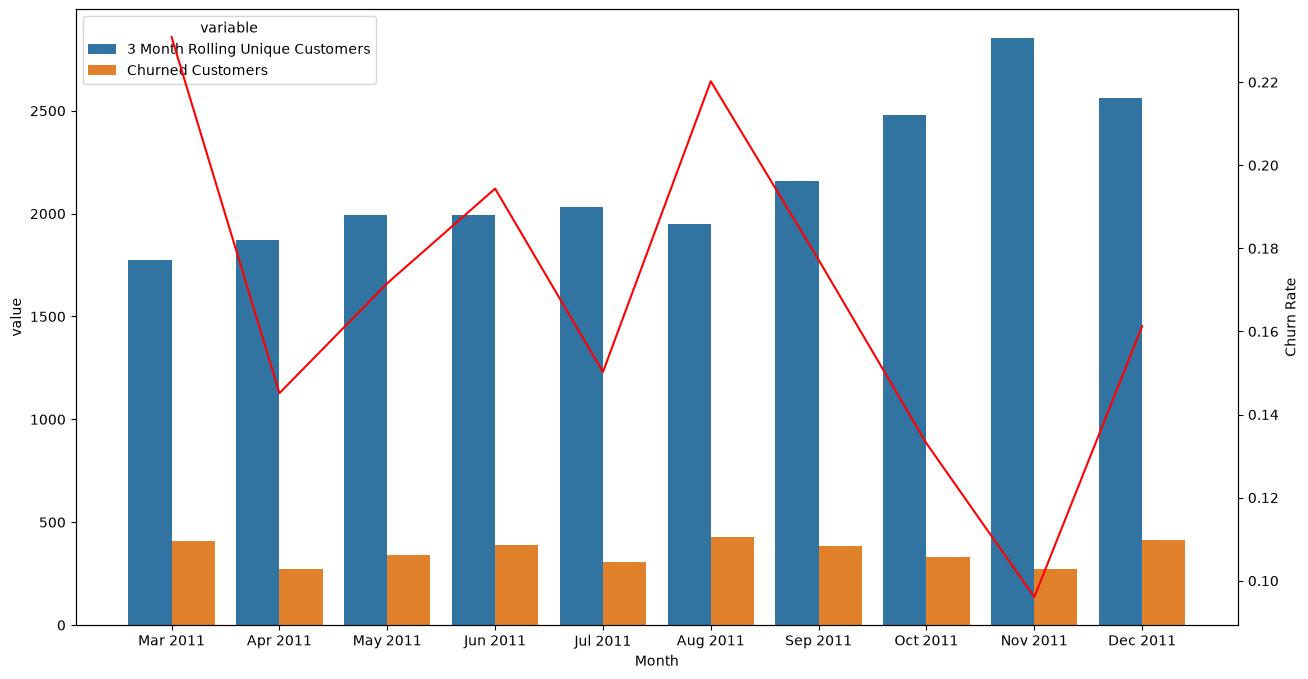

In [91]:
# Plot 3 month rolling unique customers and churned customers
fig, ax1 = plt.subplots(figsize = (15, 8))

churn_stats_melted = pd.melt(monthly_churn_stats,
                             value_vars = ['3 Month Rolling Unique Customers','Churned Customers','Churn Rate'],
                             ignore_index = False)\
                        .reset_index()\
                        .rename(columns = {'index':'Month'})
                                           

sns.barplot(churn_stats_melted[churn_stats_melted['variable'] != 'Churn Rate'],
            x = 'Month',
            y = 'value',
            hue = 'variable',
           ax = ax1)

ax2 = ax1.twinx()

sns.lineplot(monthly_churn_stats.reset_index(),
             x = np.arange(len(monthly_churn_stats)),
             y = 'Churn Rate',
             color = 'red',
            ax = ax2)

xticklabels = [churn_stats_melted['Month'].unique()[int(tick)].strftime('%b %Y')
               for tick in ax1.get_xticks()]
ax1.set_xticklabels(xticklabels)

plt.show()

In [89]:
churn_stats_melted

,Month,variable,value
0,2011-03-31,3 Month Rolling Unique Customers,1776.000000
1,2011-04-30,3 Month Rolling Unique Customers,1874.000000
2,2011-05-31,3 Month Rolling Unique Customers,1993.000000
3,2011-06-30,3 Month Rolling Unique Customers,1991.000000
4,2011-07-31,3 Month Rolling Unique Customers,2030.000000
5,2011-08-31,3 Month Rolling Unique Customers,1948.000000
6,2011-09-30,3 Month Rolling Unique Customers,2161.000000
7,2011-10-31,3 Month Rolling Unique Customers,2480.000000
8,2011-11-30,3 Month Rolling Unique Customers,2852.000000
9,2011-12-31,3 Month Rolling Unique Customers,2561.000000


# Churn Prediction
## Removing Outliers

This section narrows the dataset to a cleaner subset of customer-level spend records and removes extreme values that could distort the analysis.

The motivation is to keep the later predictive comparison focused on the most representative customer transaction patterns while noting that this filtering decision is itself a modeling assumption.


In [125]:
rfm_merge.head(5)

,,NumInvoices,LastInvoiceDate,day_since_last_purchase,AvgDaysBetweenPurchases,VarDaysBetweenPurchases,TotalSpend,AvgSpend
CustomerID,Country,,,,,,,
12346.0,United Kingdom,1,2011-01-18 10:01:00,347,NaN,NaN,77183.60,77183.600000
12347.0,Iceland,7,2011-12-07 15:52:00,24,60.333333,341.466667,4310.00,615.714286
12348.0,Finland,4,2011-09-25 13:13:00,97,94.000000,4921.000000,1797.24,449.310000
12349.0,Italy,1,2011-11-21 09:51:00,40,NaN,NaN,1757.55,1757.550000
12350.0,Norway,1,2011-02-02 16:01:00,332,NaN,NaN,334.40,334.400000


In [94]:
first_purchase_date.head(5)

,,FirstInvoiceDate,Cohort
CustomerID,Country,,
12346.0,United Kingdom,2011-01-18 10:01:00,Jan 2011
12347.0,Iceland,2010-12-07 14:57:00,Dec 2010
12348.0,Finland,2010-12-16 19:09:00,Dec 2010
12349.0,Italy,2011-11-21 09:51:00,Nov 2011
12350.0,Norway,2011-02-02 16:01:00,Feb 2011


In [126]:
# Merge rfm_merge and first_purchase_date to get the first purchase date for each customer
customer_data = pd.merge(rfm_merge,
                         first_purchase_date,
                         on=['CustomerID', 'Country'],
                         how='left')

In [127]:
customer_data.head(5)

,,NumInvoices,LastInvoiceDate,day_since_last_purchase,AvgDaysBetweenPurchases,VarDaysBetweenPurchases,TotalSpend,AvgSpend,FirstInvoiceDate,Cohort
CustomerID,Country,,,,,,,,,
12346.0,United Kingdom,1,2011-01-18 10:01:00,347,NaN,NaN,77183.60,77183.600000,2011-01-18 10:01:00,Jan 2011
12347.0,Iceland,7,2011-12-07 15:52:00,24,60.333333,341.466667,4310.00,615.714286,2010-12-07 14:57:00,Dec 2010
12348.0,Finland,4,2011-09-25 13:13:00,97,94.000000,4921.000000,1797.24,449.310000,2010-12-16 19:09:00,Dec 2010
12349.0,Italy,1,2011-11-21 09:51:00,40,NaN,NaN,1757.55,1757.550000,2011-11-21 09:51:00,Nov 2011
12350.0,Norway,1,2011-02-02 16:01:00,332,NaN,NaN,334.40,334.400000,2011-02-02 16:01:00,Feb 2011


In [52]:
# IQR to remove outliers
data_grouped_desc = data_grouped['TotalPrice'].describe()

data_grouped_desc

count     16766.000000
mean        531.516635
std        1907.700011
min           0.000000
25%         178.710000
50%         311.310000
75%         498.167500
max      168469.600000
Name: TotalPrice, dtype: float64

In [53]:
iqr = data_grouped_desc['75%'] - data_grouped_desc['25%']

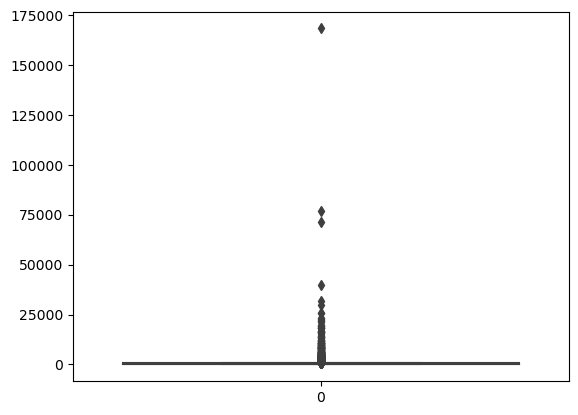

In [54]:
sns.boxplot(data_grouped['TotalPrice'])
plt.show()

In [55]:
data_lower_bound = data_grouped_desc['25%'] - 1.5*iqr
data_upper_bound = data_grouped_desc['75%'] + 1.5*iqr

print('Lower Bound: %.2f' % data_lower_bound)
print('Upper Bound: %.2f' % data_upper_bound)

Lower Bound: -300.48
Upper Bound: 977.35


### Countries

The notebook restricts the churn prediction exercise to the three countries that make up the largest share of the customer base: the United Kingdom, Germany, and France.

This step reduces noise from very small country segments and keeps the downstream analysis focused on the most relevant customer populations.


In [56]:
country_unique_customers = data_grouped.groupby('Country')\
                            [['CustomerID']]\
                            .nunique()\
                            .sort_values('CustomerID',
                                         ascending = False)\
                            .rename(columns = {'CustomerID':'UniqueCustomers'})

In [57]:
country_unique_customers['PctCustomers'] = country_unique_customers['UniqueCustomers']/country_unique_customers['UniqueCustomers'].sum() * 100

In [58]:
country_unique_customers[country_unique_customers['PctCustomers'] > 1]

,UniqueCustomers,PctCustomers
Country,,
United Kingdom,3921,90.200138
Germany,94,2.162411
France,87,2.001380


In [59]:
pct_other_countries = 100 - country_unique_customers[country_unique_customers.index.isin(['United Kingdom','France','Germany'])]['PctCustomers'].sum()

print('Percent of Customers outside UK, France, and Germany: %.2f' % pct_other_countries)

Percent of Customers outside UK, France, and Germany: 5.64


I'm only keeping the United Kingdom, Germany, and France because they each represent more than $1\%$ of the customer base. This helps avoid over-interpreting very small groups that could otherwise produce unstable churn or correlation results.


In [60]:
# Lower bound is negative
percent_remaining_data = len(data_grouped[(data_grouped['TotalPrice'] >= data_lower_bound)
                             & (data_grouped['TotalPrice'] <= data_upper_bound)
                             & (data_grouped['TotalPrice'] > 0)
                             & (data_grouped['Country'].isin(['United Kingdom',
                                                                     'Germany',
                                                                     'France']))]['TotalPrice'])/\
                        len(data_grouped['TotalPrice']) # Compared to original grouped data

print('Percent of remaining data: %f' % (percent_remaining_data * 100))

Percent of remaining data: 87.749016


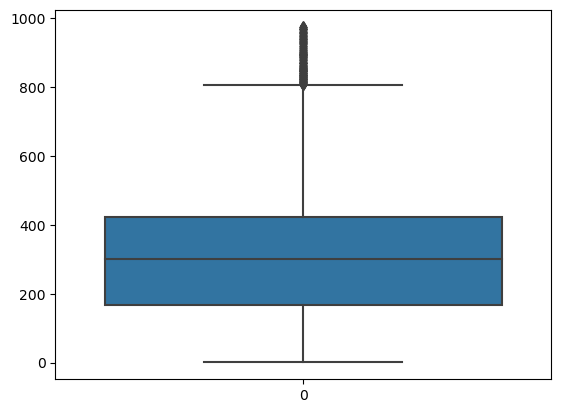

In [61]:
sns.boxplot(data_grouped[(data_grouped['TotalPrice'] >= data_lower_bound)
                             & (data_grouped['TotalPrice'] <= data_upper_bound)
                             & (data_grouped['TotalPrice'] > 0)
                             & (data_grouped['Country'].isin(['United Kingdom',
                                                                     'Germany',
                                                                     'France']))]\
            .reset_index(drop = True)['TotalPrice'])
plt.show()

In [62]:
data_bounded = data_grouped[(data_grouped['TotalPrice'] >= data_lower_bound)
                             & (data_grouped['TotalPrice'] <= data_upper_bound)
                             & (data_grouped['TotalPrice'] > 0)
                             & (data_grouped['Country'].isin(['United Kingdom',
                                                              'Germany',
                                                              'France']))]

In [63]:
features = data_bounded\
            .groupby(['CustomerID','InvoiceDate','Country'])\
            [['Quantity','TotalPrice']]\
            .sum()\
            .reset_index()

In [64]:
data_merged = pd.merge(features,
                       data_agg,
                       how = 'outer',
                       left_on = ['CustomerID','Country','InvoiceDate'],
                       right_on = ['CustomerID','Country','InvoiceDate'])

In [65]:
# United Kingdom Correlation
data_merged[data_merged['Country'] == 'United Kingdom']\
                [['Quantity','TotalPrice',
                  'RollingQuantity','RollingTotalPrice',
                  'Churn']].corr()

,Quantity,TotalPrice,RollingQuantity,RollingTotalPrice,Churn
Quantity,1.000000,0.667220,0.239560,0.140315,-0.067462
TotalPrice,0.667220,1.000000,0.198216,0.185215,-0.088357
RollingQuantity,0.239560,0.198216,1.000000,0.880698,-0.158165
RollingTotalPrice,0.140315,0.185215,0.880698,1.000000,-0.137618
Churn,-0.067462,-0.088357,-0.158165,-0.137618,1.000000


In [66]:
# France Correlation
data_merged[data_merged['Country'] == 'France']\
                [['Quantity','TotalPrice',
                  'RollingQuantity','RollingTotalPrice',
                  'Churn']].corr()

,Quantity,TotalPrice,RollingQuantity,RollingTotalPrice,Churn
Quantity,1.000000,0.794454,0.331323,0.251360,-0.108825
TotalPrice,0.794454,1.000000,0.357779,0.356726,-0.130545
RollingQuantity,0.331323,0.357779,1.000000,0.966060,-0.300905
RollingTotalPrice,0.251360,0.356726,0.966060,1.000000,-0.291080
Churn,-0.108825,-0.130545,-0.300905,-0.291080,1.000000


In [67]:
# Germany Correlation
data_merged[data_merged['Country'] == 'Germany']\
                [['Quantity','TotalPrice',
                  'RollingQuantity','RollingTotalPrice',
                  'Churn']].corr()

,Quantity,TotalPrice,RollingQuantity,RollingTotalPrice,Churn
Quantity,1.000000,0.795136,0.336647,0.243465,0.001993
TotalPrice,0.795136,1.000000,0.292767,0.319531,-0.024462
RollingQuantity,0.336647,0.292767,1.000000,0.933468,-0.226683
RollingTotalPrice,0.243465,0.319531,0.933468,1.000000,-0.230456
Churn,0.001993,-0.024462,-0.226683,-0.230456,1.000000


Based on the available data, the churn prediction section does not show a strong relationship between `Quantity`, `TotalPrice`, and churn. That suggests the notebook's simple value features are not sufficient on their own to explain churn behavior.

This is an important modeling takeaway: stronger churn prediction would likely require more behavioral, temporal, or transactional features.


In [ ]:
with pd.ExcelWriter('./Data/Online Retail_Churn.xlsx') as writer:
    data_merged.to_excel(writer,
                          sheet_name = 'Churn',
                          index = False)